In [ ]:
%pip install osmnx
%pip install pandas
%pip install networkx
%pip install matplotlib
%pip install scipy

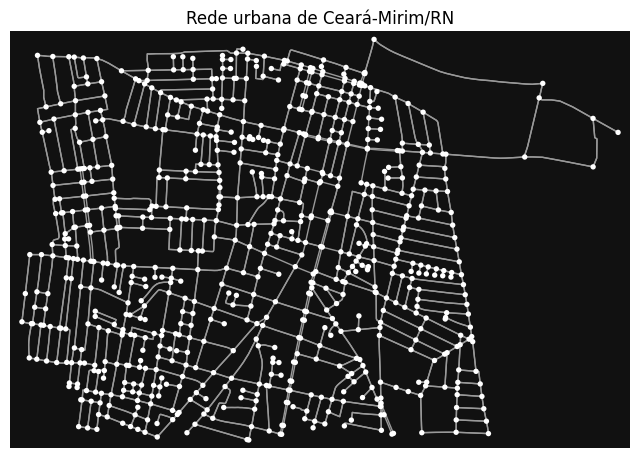

--------- Informações do Grafo ---------
Número de nós: 777
Número de arestas: 2112
----------------------------------------


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

local_escolhido = "Ceará-Mirim, Ceará-Mirim, RN, Brazil"
G = ox.graph_from_address(local_escolhido, dist=1800, network_type="drive")


fig, ax = ox.plot.plot_graph(G, show=False, close=False)
ax.set_title("Rede urbana de Ceará-Mirim/RN")
plt.show()

print("--------- Informações do Grafo ---------")
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")
print("----------------------------------------")

In [3]:
# Conversão para grafo simples para cálculos de centralidade
G_undirected = ox.convert.to_undirected(G)
G_simple = nx.Graph(G_undirected)

# Cálculos principais
degree_dict = dict(G_simple.degree())
betweenness = nx.betweenness_centrality(G_simple, k=100)
closeness = nx.closeness_centrality(G_simple)
core_number = nx.core_number(G_simple)

# Salva as métricas como atributos do grafo
nx.set_node_attributes(G_simple, degree_dict, "degree")
nx.set_node_attributes(G_simple, betweenness, "betweenness")
nx.set_node_attributes(G_simple, closeness, "closeness")
nx.set_node_attributes(G_simple, core_number, "core_number")

In [4]:
# Função para plotar os nós destacados
def plot_highlighted_nodes(G_plot, coords, color, title):
    fig, ax = ox.plot_graph(
        G_plot,
        show=False,
        close=False,
        edge_color="#bbbbbb",
        edge_alpha=0.3,
        node_size=0,
        edge_linewidth=0.8,
    )
    ax.scatter(
        coords.geometry.x,
        coords.geometry.y,
        c=color,
        s=80,
        edgecolors="black",
        linewidths=1,
        zorder=10,
    )
    ax.set_title(title)
    plt.show()

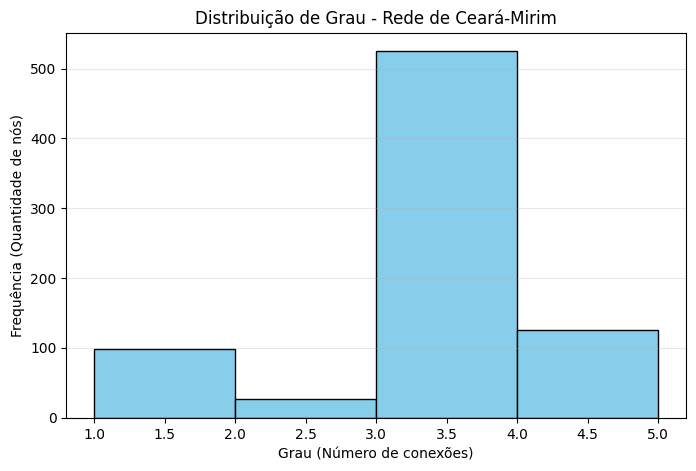

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(
    degree_dict.values(),
    bins=range(min(degree_dict.values()), max(degree_dict.values()) + 2),
    color='skyblue', edgecolor='black'
)

plt.title("Distribuição de Grau - Rede de Ceará-Mirim")
plt.xlabel("Grau (Número de conexões)")
plt.ylabel("Frequência (Quantidade de nós)")
plt.grid(axis='y', alpha=0.3)
plt.show()

Top 10 Hubs (maior grau):


,Nó_ID,Grau,Betweenness,Core_Number
67,2069259074,4,0.008137,2
288,2071556063,4,0.037286,2
209,2071038302,4,0.251939,2
210,2071040889,4,0.186722,2
101,2070974708,4,0.035064,2
297,2071562870,4,0.017693,2
734,7015999544,4,0.035374,2
6,2069035933,4,0.112410,2
203,2071033136,4,0.104672,2
44,2069258161,4,0.013132,2


Gerando mapa de hubs (maiores cruzamentos)...


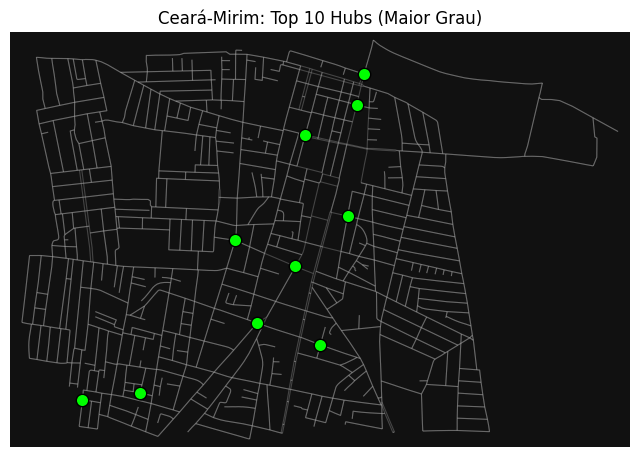

In [6]:
# Projeta o grafo para alinhar as coordenadas com o mapa
G_proj = ox.project_graph(G)
nodes_proj, _ = ox.graph_to_gdfs(G_proj)

df_metrics = pd.DataFrame({
    "Nó_ID": list(degree_dict.keys()),
    "Grau": list(degree_dict.values()),
    "Betweenness": [betweenness[n] for n in degree_dict],
    "Core_Number": [core_number[n] for n in degree_dict],
})

print("Top 10 Hubs (maior grau):")
display(df_metrics.sort_values(by="Grau", ascending=False).head(10))

top_10_hubs_df = df_metrics.sort_values(by="Grau", ascending=False).head(10)
top_10_hubs_ids = top_10_hubs_df["Nó_ID"].tolist()
top_hubs_coords = nodes_proj.loc[top_10_hubs_ids]

print("Gerando mapa de hubs (maiores cruzamentos)...")
plot_highlighted_nodes(
    G_proj,
    top_hubs_coords,
    "#00FF00",
    "Ceará-Mirim: Top 10 Hubs (Maior Grau)",
)

Gerando mapa de pontos críticos...


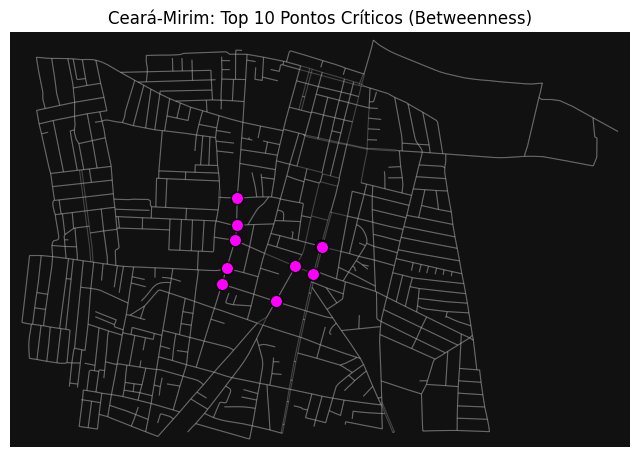


--- TABELA DE PONTOS CRÍTICOS (CEARÁ-MIRIM) ---


,Nó_ID,Betweenness,Grau,Core_Number
0,2071038302,0.25194,4,2
1,4925355720,0.23610,4,2
2,4913846387,0.20711,4,2
3,2055840430,0.20171,3,2
4,2299931002,0.19849,4,2
5,2071040889,0.18672,4,2
6,2071542794,0.15947,4,2
7,2071502478,0.15805,4,2
8,2071516078,0.13870,4,2
9,2071025728,0.13674,3,2


In [7]:
top_10_df = df_metrics.sort_values(by="Betweenness", ascending=False).head(10)
top_10_ids = top_10_df["Nó_ID"].tolist()
top_nodes_coords = nodes_proj.loc[top_10_ids]

print("Gerando mapa de pontos críticos...")
plot_highlighted_nodes(
    G_proj,
    top_nodes_coords,
    "#FF00FF",
    "Ceará-Mirim: Top 10 Pontos Críticos (Betweenness)",
)

print("\n--- TABELA DE PONTOS CRÍTICOS (CEARÁ-MIRIM) ---")
tabela_relatorio = top_10_df[["Nó_ID", "Betweenness", "Grau", "Core_Number"]].copy()

tabela_relatorio["Betweenness"] = tabela_relatorio["Betweenness"].map("{:.5f}".format)
display(tabela_relatorio.reset_index(drop=True))

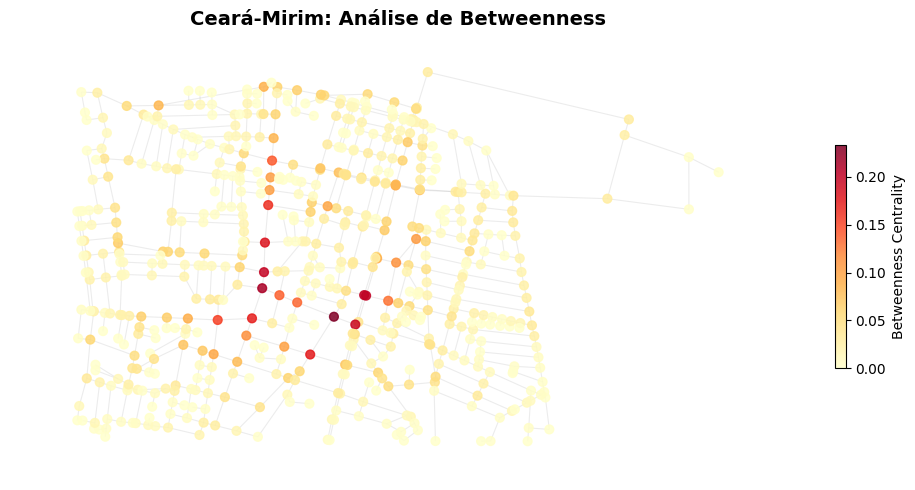

In [8]:
G_drive = ox.graph_from_address(local_escolhido, dist=1500, network_type="drive")

Gs = nx.Graph(G_drive) if G_drive.is_multigraph() else G_drive.copy()
Gs.remove_edges_from(nx.selfloop_edges(Gs))

graus = dict(Gs.degree())
betweenness = nx.betweenness_centrality(Gs, k=100, normalized=True)
closeness = nx.closeness_centrality(Gs)
core_number = nx.core_number(Gs)
pagerank = nx.pagerank(Gs, max_iter=200)

try:
    eigenvector = nx.eigenvector_centrality(Gs, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {n: 0.0 for n in Gs.nodes()}

# DataFrame de resultados
df = pd.DataFrame({
    'node_id': list(Gs.nodes()),
    'degree': [graus[n] for n in Gs.nodes()],
    'betweenness': [betweenness.get(n, 0) for n in Gs.nodes()],
    'closeness': [closeness[n] for n in Gs.nodes()],
    'core_number': [core_number[n] for n in Gs.nodes()],
    'pagerank': [pagerank[n] for n in Gs.nodes()],
    'eigenvector': [eigenvector[n] for n in Gs.nodes()],
})

# Coordenadas
df['x'] = [Gs.nodes[n].get('x', 0) for n in Gs.nodes()]
df['y'] = [Gs.nodes[n].get('y', 0) for n in Gs.nodes()]


fig, ax = plt.subplots(figsize=(10, 5))

titulo_grafico = 'Ceará-Mirim: Análise de Betweenness'

# Preparação do Grafo para desenho
Gs = nx.Graph(G_drive) if G_drive.is_multigraph() else G_drive
pos = {n: (Gs.nodes[n].get('x', 0), Gs.nodes[n].get('y', 0)) for n in Gs.nodes()}

# Mapeamento de cores baseado na Betweenness (Heatmap)
valores_betweenness = [df.loc[df['node_id'] == n, 'betweenness'].values[0] for n in Gs.nodes()]

# Desenho das arestas (fundo sutil)
nx.draw_networkx_edges(Gs, pos, ax=ax, alpha=0.15, edge_color='gray', width=0.8)

# Desenho dos nós (Heatmap)
nodes = nx.draw_networkx_nodes(
    Gs,
    pos,
    ax=ax,
    node_color=valores_betweenness,
    node_size=40,
    cmap='YlOrRd',
    alpha=0.85
  )

# Barra de cor lateral
plt.colorbar(nodes, ax=ax, label='Betweenness Centrality', shrink=0.5)

ax.set_title(titulo_grafico, fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

=== K-CORES EXISTENTES NA REDE ===
1     88
2    501
Name: count, dtype: int64

Valores de k: [1, 2]
Maior k encontrado: 2
Ceará-Mirim: Filtrando para k >= 2
Nós no núcleo: 501


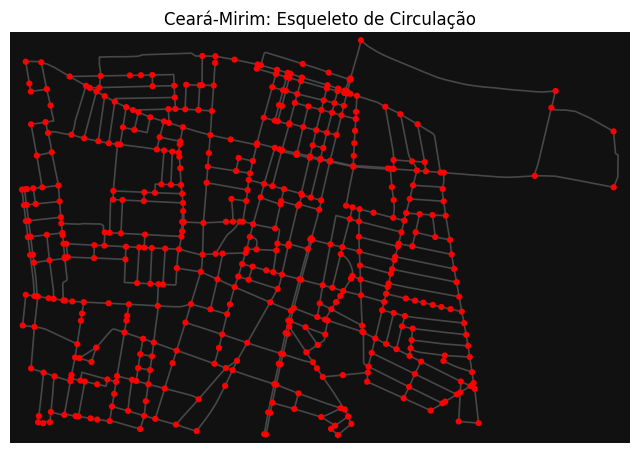

In [9]:
# Análise dos k-cores existentes
print("=== K-CORES EXISTENTES NA REDE ===")
k_distribution = pd.Series(core_number).value_counts().sort_index()
print(k_distribution)
print(f"\nValores de k: {sorted(k_distribution.index.tolist())}")
print(f"Maior k encontrado: {k_distribution.index.max()}")
print("==================================")
# Filtrando os nós (k >= 2)
k_filter = 2
nodes_to_keep = [n for n, core in core_number.items() if core >= k_filter]

# Criando subgrafo simples
G_core_simple = G_simple.subgraph(nodes_to_keep).copy()

# O OSMnx só plota objetos que tenham chaves de aresta (keys)
G_core_multi = nx.MultiGraph(G_core_simple)

# Restaura metadados de projeção para o mapa não sair deformado
G_core_multi.graph = G.graph

print(f"Ceará-Mirim: Filtrando para k >= {k_filter}")
print(f"Nós no núcleo: {len(G_core_multi.nodes())}")

# Plotagem
fig, ax = ox.plot_graph(
    G_core_multi,
    node_size=20,
    node_color="red",
    edge_color="#555555",
    edge_linewidth=1.2,
    edge_alpha=0.8,
    show=False,
    close=False
)

ax.set_title("Ceará-Mirim: Esqueleto de Circulação")
plt.show()